Unemployment Analysis in India using Python
CodeAlpha Data Science Internship - Task 2
### Author: Shreya

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Unemployment in India.csv to Unemployment in India (1).csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
sns.set_theme()

import warnings
warnings.filterwarnings("ignore")

In [ ]:
df = pd.read_csv("Unemployment in India.csv")
df

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural
...,...,...,...,...,...,...,...
763,NaN,NaN,NaN,NaN,NaN,NaN,NaN
764,NaN,NaN,NaN,NaN,NaN,NaN,NaN
765,NaN,NaN,NaN,NaN,NaN,NaN,NaN
766,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
print("Rows and Columns:", df.shape)
df.info()

Rows and Columns: (768, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB


In [ ]:
df.columns = df.columns.str.strip()

df.rename(columns={
    "Estimated Unemployment Rate (%)":"Unemployment_Rate",
    "Estimated Employed":"Employed",
    "Estimated Labour Participation Rate (%)":"Labour_Participation_Rate"
}, inplace=True)

df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)
df

,Region,Date,Frequency,Unemployment_Rate,Employed,Labour_Participation_Rate,Area
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.0,44.68,Rural
...,...,...,...,...,...,...,...
763,NaN,NaT,NaN,NaN,NaN,NaN,NaN
764,NaN,NaT,NaN,NaN,NaN,NaN,NaN
765,NaN,NaT,NaN,NaN,NaN,NaN,NaN
766,NaN,NaT,NaN,NaN,NaN,NaN,NaN


In [ ]:
df.isnull().sum()

,0
Region,28
Date,28
Frequency,28
Unemployment_Rate,28
Employed,28
Labour_Participation_Rate,28
Area,28


In [ ]:
df.dropna(inplace=True)
df.head()

,Region,Date,Frequency,Unemployment_Rate,Employed,Labour_Participation_Rate,Area
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.0,44.68,Rural


In [ ]:
df.describe()

,Date,Unemployment_Rate,Employed,Labour_Participation_Rate
count,740,740.000000,7.400000e+02,740.000000
mean,2019-12-12 18:36:58.378378496,11.787946,7.204460e+06,42.630122
min,2019-05-31 00:00:00,0.000000,4.942000e+04,13.330000
25%,2019-08-31 00:00:00,4.657500,1.190404e+06,38.062500
50%,2019-11-30 00:00:00,8.350000,4.744178e+06,41.160000
75%,2020-03-31 00:00:00,15.887500,1.127549e+07,45.505000
max,2020-06-30 00:00:00,76.740000,4.577751e+07,72.570000
std,NaN,10.721298,8.087988e+06,8.111094


In [ ]:
df.isnull().sum()

,0
Region,0
Date,0
Frequency,0
Unemployment_Rate,0
Employed,0
Labour_Participation_Rate,0
Area,0


In [ ]:
print("Average Unemployment Rate:")

print(round(df["Unemployment_Rate"].mean(),2),"%")

Average Unemployment Rate:
11.79 %


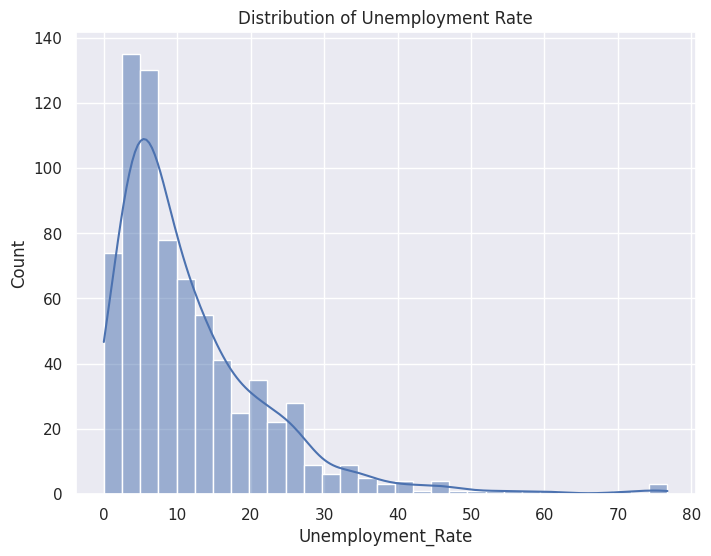

In [ ]:
plt.figure(figsize=(8,6))

sns.histplot(
    df["Unemployment_Rate"],
    kde=True
)

plt.title("Distribution of Unemployment Rate")

plt.show()

In [ ]:
state_rate = df.groupby("Region")["Unemployment_Rate"]\
               .mean()\
               .sort_values(ascending=False)

state_rate.head(10)

,Unemployment_Rate
Region,
Tripura,28.350357
Haryana,26.283214
Jharkhand,20.585000
Bihar,18.918214
Himachal Pradesh,18.540357
Delhi,16.495357
Jammu & Kashmir,16.188571
Chandigarh,15.991667
Rajasthan,14.058214


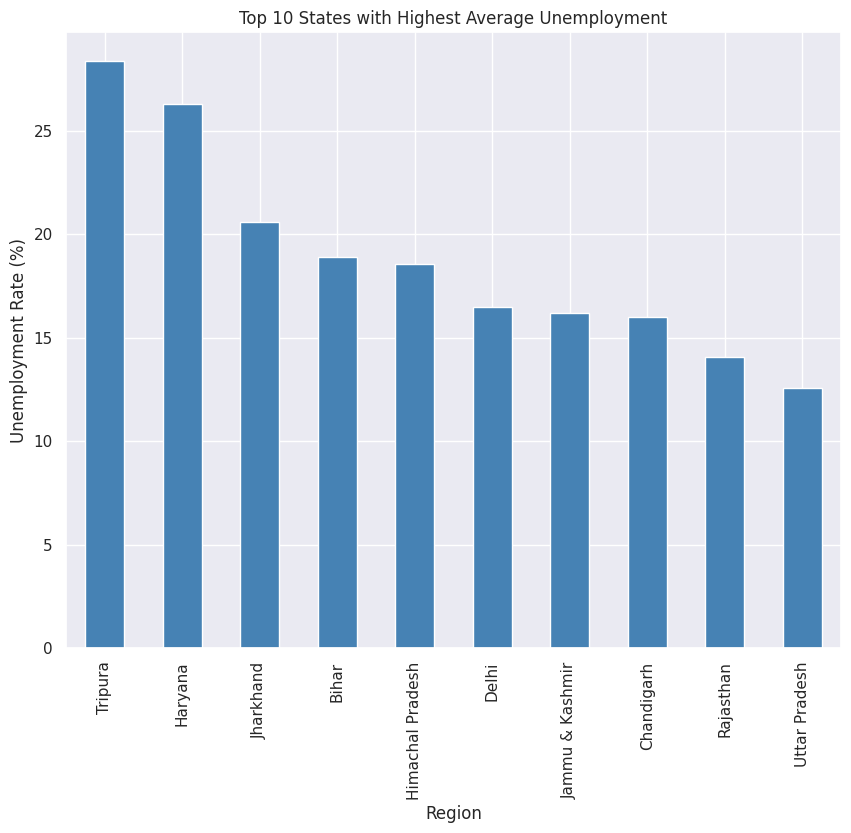

In [ ]:
plt.figure(figsize=(10,8))

state_rate.head(10).plot(
    kind="bar",
    color="steelblue"
)

plt.title("Top 10 States with Highest Average Unemployment")
plt.ylabel("Unemployment Rate (%)")

plt.show()

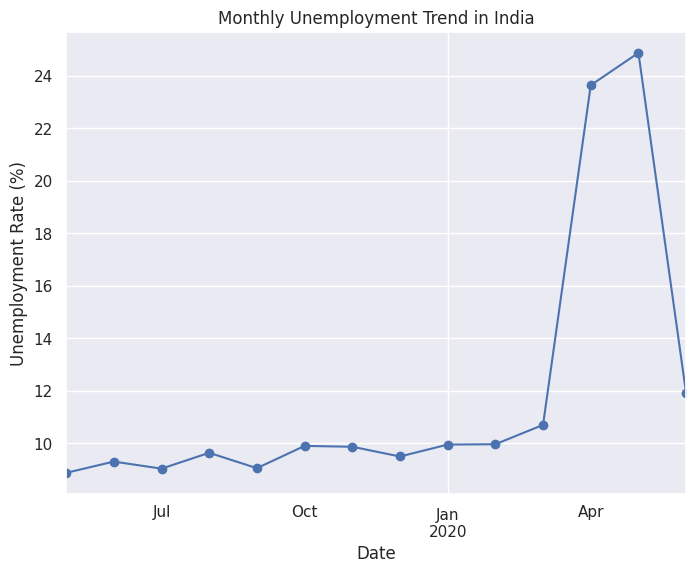

In [ ]:
monthly_trend = df.groupby("Date")["Unemployment_Rate"].mean()

plt.figure(figsize=(8,6))

monthly_trend.plot(
    marker="o"
)

plt.title("Monthly Unemployment Trend in India")
plt.ylabel("Unemployment Rate (%)")

plt.show()

In [ ]:
pre_covid = df[df["Date"] < "2020-03-01"]

covid = df[df["Date"] >= "2020-03-01"]

In [ ]:
pre_rate = pre_covid["Unemployment_Rate"].mean()

covid_rate = covid["Unemployment_Rate"].mean()

comparison = pd.DataFrame({
    "Period":["Pre-Covid","Covid"],
    "Rate":[pre_rate,covid_rate]
})

comparison

,Period,Rate
0,Pre-Covid,9.509534
1,Covid,17.774363


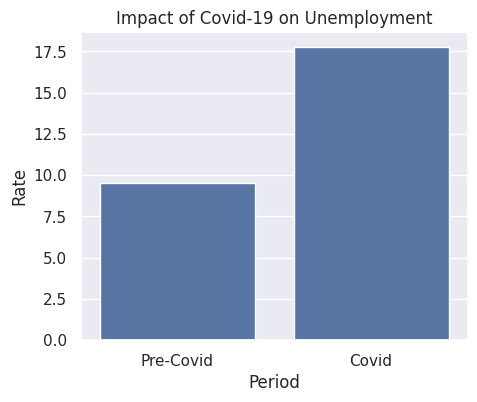

In [ ]:
plt.figure(figsize=(5,4))

sns.barplot(
    data=comparison,
    x="Period",
    y="Rate"
)

plt.title("Impact of Covid-19 on Unemployment")

plt.show()

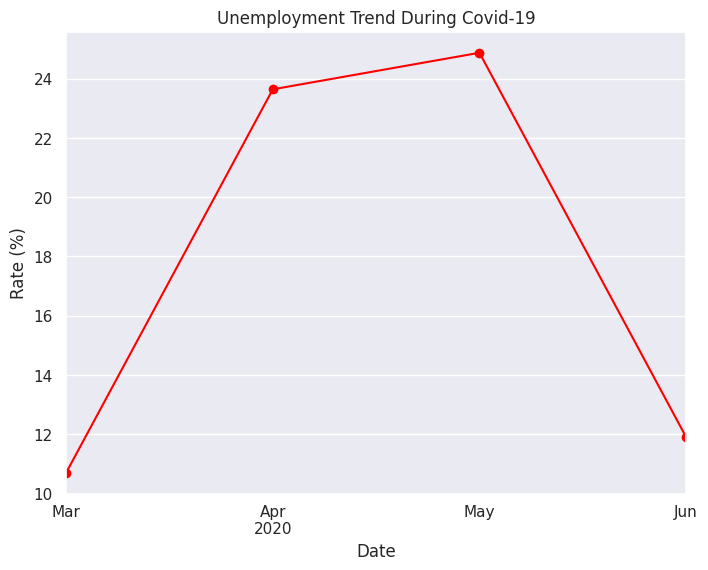

In [ ]:
covid_monthly = covid.groupby("Date")["Unemployment_Rate"].mean()

plt.figure(figsize=(8,6))

covid_monthly.plot(
    color="red",
    marker="o"
)

plt.title("Unemployment Trend During Covid-19")

plt.ylabel("Rate (%)")

plt.show()

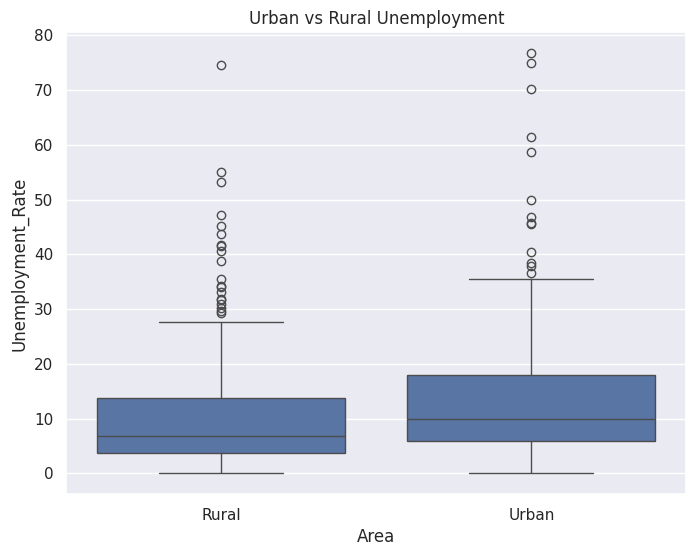

In [ ]:
plt.figure(figsize=(8,6))

sns.boxplot(
    x="Area",
    y="Unemployment_Rate",
    data=df
)

plt.title("Urban vs Rural Unemployment")

plt.show()

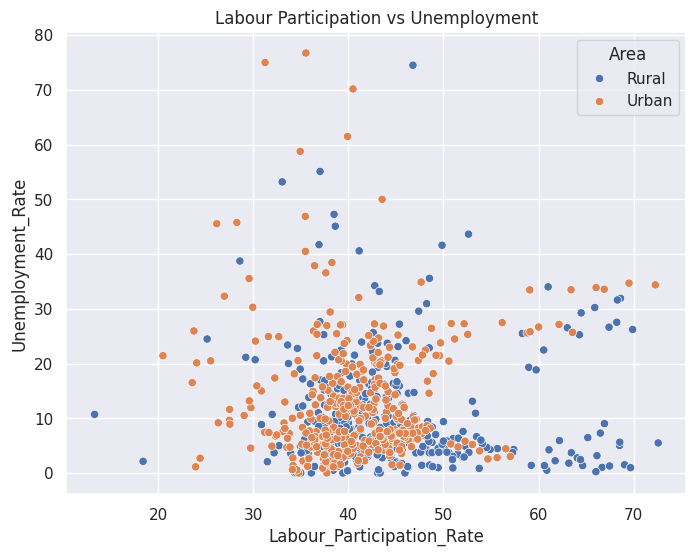

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x="Labour_Participation_Rate",
    y="Unemployment_Rate",
    hue="Area",
    data=df
)

plt.title("Labour Participation vs Unemployment")

plt.show()

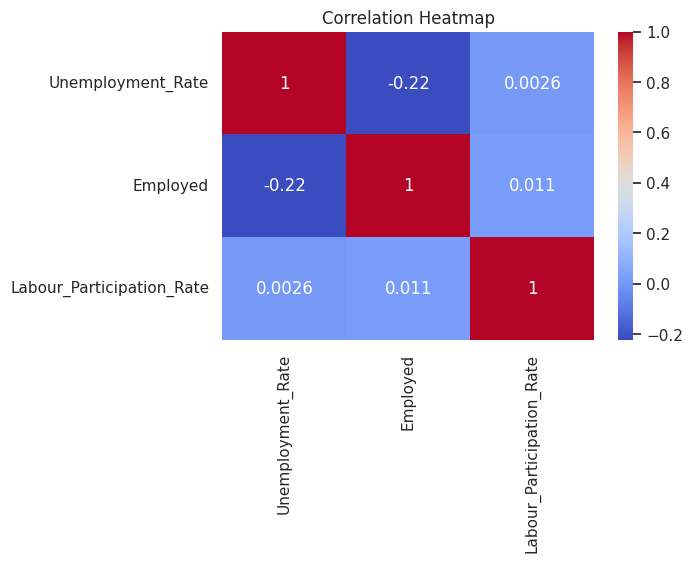

In [ ]:
corr = df[
    [
        "Unemployment_Rate",
        "Employed",
        "Labour_Participation_Rate"
    ]
].corr()

plt.figure(figsize=(6,4))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

In [ ]:
df["Month"] = df["Date"].dt.month_name()

month_order = [
    'January','February','March',
    'April','May','June',
    'July','August','September',
    'October','November','December'
]

monthly_pattern = df.groupby("Month")["Unemployment_Rate"]\
                    .mean()\
                    .reindex(month_order)

monthly_pattern

,Unemployment_Rate
Month,
January,9.950755
February,9.964717
March,10.700577
April,23.641569
May,16.646190
June,10.553462
July,9.033889
August,9.637925
September,9.051731


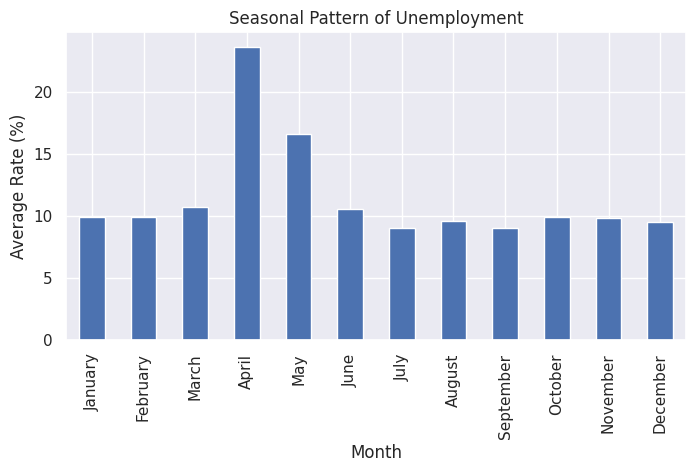

In [ ]:
plt.figure(figsize=(8,4))
monthly_pattern.plot(
    kind="bar"
)
plt.title("Seasonal Pattern of Unemployment")
plt.ylabel("Average Rate (%)")

plt.show()

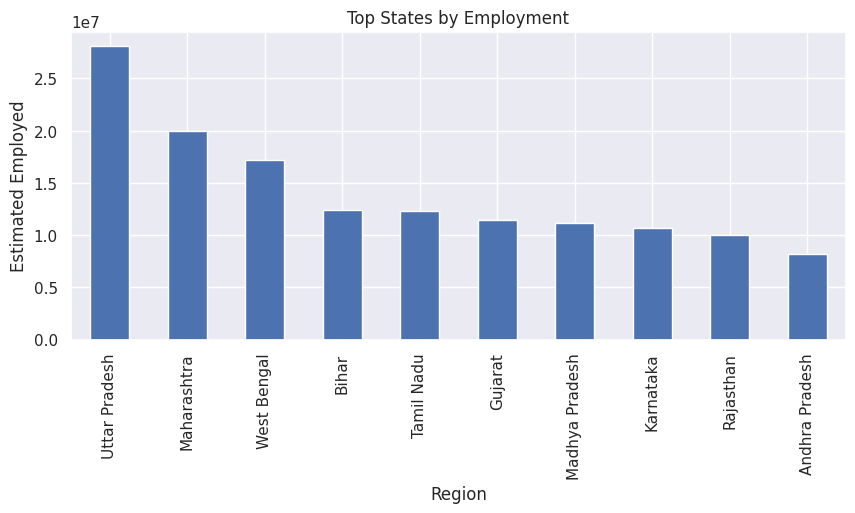

In [ ]:
employment = df.groupby("Region")["Employed"]\
               .mean()\
               .sort_values(ascending=False)\
               .head(10)

plt.figure(figsize=(10,4))
employment.plot(
    kind="bar"
)
plt.title("Top States by Employment")
plt.ylabel("Estimated Employed")

plt.show()

# **Create an Unemployment Dashboard**

In [ ]:
!pip install plotly

In [ ]:
import plotly.express as px

fig = px.histogram(
    df.head(100),
    x='Date',
    y='Unemployment_Rate',
    color='Region',
    title='State-wise Unemployment Trends'

)

fig.show()

### **Find States Most Affected by Covid**

<Axes: xlabel='Region'>

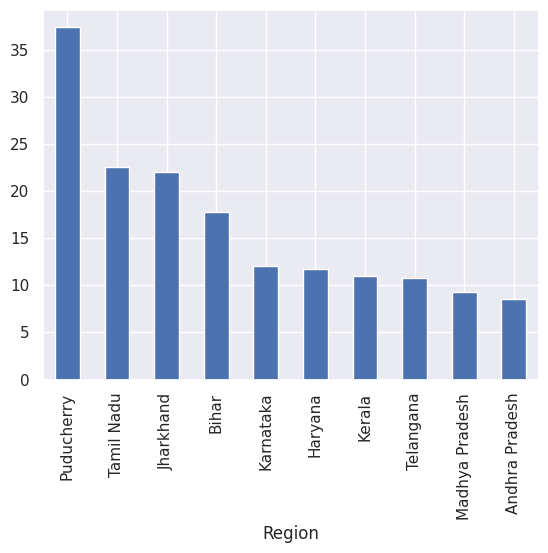

In [ ]:
pre = pre_covid.groupby('Region')['Unemployment_Rate'].mean()

post = covid.groupby('Region')['Unemployment_Rate'].mean()

impact = (post - pre).sort_values(ascending=False)

impact.head(10)
impact.head(10).plot(kind='bar')

## **Create a State Ranking System**

In [ ]:
state_rank = df.groupby('Region')['Unemployment_Rate'].mean()

state_rank = state_rank.sort_values()

state_rank

,Unemployment_Rate
Region,
Meghalaya,4.798889
Odisha,5.657857
Assam,6.428077
Uttarakhand,6.582963
Gujarat,6.663929
Karnataka,6.676071
Sikkim,7.249412
Madhya Pradesh,7.406429
Andhra Pradesh,7.477143


In [ ]:
def category(rate):
    if rate < 8:
        return 'Low'
    elif rate < 15:
        return 'Moderate'
    else:
        return 'High'

ranking = state_rank.reset_index()

ranking['Category'] = ranking[
    'Unemployment_Rate'
].apply(category)
ranking

,Region,Unemployment_Rate,Category
0,Meghalaya,4.798889,Low
1,Odisha,5.657857,Low
2,Assam,6.428077,Low
3,Uttarakhand,6.582963,Low
4,Gujarat,6.663929,Low
5,Karnataka,6.676071,Low
6,Sikkim,7.249412,Low
7,Madhya Pradesh,7.406429,Low
8,Andhra Pradesh,7.477143,Low
9,Maharashtra,7.557500,Low


## **Forecast Future Unemployment**

In [ ]:
from sklearn.linear_model import LinearRegression
monthly = df.groupby('Date')[
    'Unemployment_Rate'
].mean().reset_index()

monthly['Days'] = (
    monthly['Date']
    - monthly['Date'].min()
).dt.days
X = monthly[['Days']]
y = monthly['Unemployment_Rate']

model = LinearRegression()

model.fit(X,y)

LinearRegression()

## **Covid Lockdown Peak Detection**

Region                                Puducherry
Date                         2020-04-30 00:00:00
Frequency                                Monthly
Unemployment_Rate                          76.74
Employed                                 68122.0
Labour_Participation_Rate                  35.54
Area                                       Urban
Month                                      April
Name: 627, dtype: object


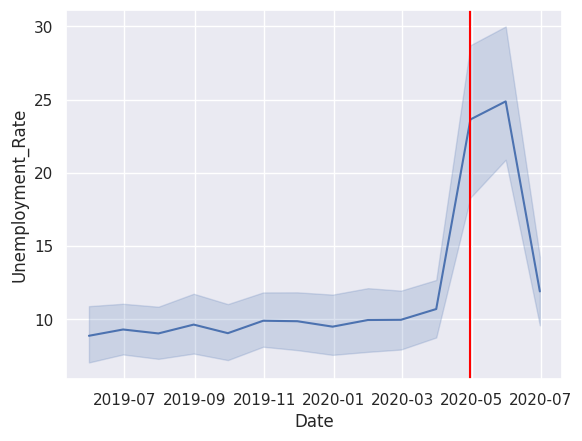

In [ ]:
peak = df.loc[
    df['Unemployment_Rate'].idxmax()]
print(peak)

sns.lineplot(
    x='Date',
    y='Unemployment_Rate',
    data=df
)

plt.axvline(
    peak['Date'],
    color='red'
)

## **Create a Correlation Story**

<Axes: xlabel='Labour_Participation_Rate', ylabel='Unemployment_Rate'>

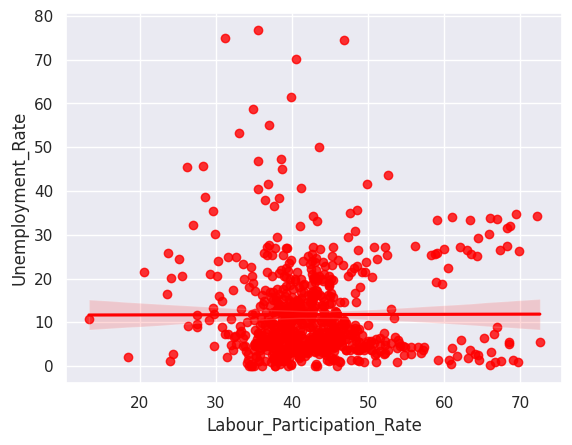

In [ ]:
sns.regplot(
    x='Labour_Participation_Rate',
    y='Unemployment_Rate',
    color='red',
    data=df
)

## **Geographic Visualization**

In [ ]:
import plotly.express as px

## **yDataProfiling Report**

In [ ]:
!pip install ydata-profiling

In [ ]:
import pandas as pd
from ydata_profiling import ProfileReport

profile = ProfileReport(
    df,
    title="CodeAlpha Unemployment Analysis Report",
    explorative=True,
    correlations={
        "pearson": {"calculate": True},
        "spearman": {"calculate": True},
        "kendall": {"calculate": True},
        "phi_k": {"calculate": True}
    },
    missing_diagrams={
        "matrix": True,
        "heatmap": True,
        "dendrogram": True
    }
)

profile.to_file("CodeAlpha_Unemployment_Report.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 8/8 [00:00<00:00, 44.63it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

KEY INSIGHTS

1. Covid-19 significantly increased unemployment levels.

2. Urban areas showed higher volatility in employment.

3. Some states consistently experienced higher unemployment rates.

4. Labour participation and unemployment exhibit measurable relationships.

5. Seasonal variations suggest economic activities affect employment patterns.


POLICY RECOMMENDATIONS

1. Expand skill development initiatives.

2. Support MSMEs during economic downturns.

3. Strengthen rural employment programs.

4. Improve labour market monitoring systems.

5. Increase social protection measures during crises.


Economic Insights

1. Covid-19 caused a sharp unemployment spike.

2. Urban areas were more vulnerable.

3. Certain states consistently showed high unemployment.

4. Employment recovery was uneven across regions.

5. Skill-based employment programs should target high-risk states.